In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("safrin03/predictive-analytics-for-customer-churn-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'predictive-analytics-for-customer-churn-dataset' dataset.
Path to dataset files: /kaggle/input/predictive-analytics-for-customer-churn-dataset


In [3]:
import os

os.listdir(path)

['data_descriptions.csv', 'train.csv', 'test.csv']

In [4]:

df_train = pd.read_csv(os.path.join(path, "train.csv"))
df_train.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [5]:
df_train.shape

(243787, 21)

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                243787 non-null  int64  
 1   MonthlyCharges            243787 non-null  float64
 2   TotalCharges              243787 non-null  float64
 3   SubscriptionType          243787 non-null  object 
 4   PaymentMethod             243787 non-null  object 
 5   PaperlessBilling          243787 non-null  object 
 6   ContentType               243787 non-null  object 
 7   MultiDeviceAccess         243787 non-null  object 
 8   DeviceRegistered          243787 non-null  object 
 9   ViewingHoursPerWeek       243787 non-null  float64
 10  AverageViewingDuration    243787 non-null  float64
 11  ContentDownloadsPerMonth  243787 non-null  int64  
 12  GenrePreference           243787 non-null  object 
 13  UserRating                243787 non-null  f

In [7]:
df_train.isnull().sum()

,0
AccountAge,0
MonthlyCharges,0
TotalCharges,0
SubscriptionType,0
PaymentMethod,0
PaperlessBilling,0
ContentType,0
MultiDeviceAccess,0
DeviceRegistered,0
ViewingHoursPerWeek,0


In [8]:
df_train.isnull().sum()/len(df_train)

,0
AccountAge,0.0
MonthlyCharges,0.0
TotalCharges,0.0
SubscriptionType,0.0
PaymentMethod,0.0
PaperlessBilling,0.0
ContentType,0.0
MultiDeviceAccess,0.0
DeviceRegistered,0.0
ViewingHoursPerWeek,0.0


#  null values and duplicates

In [9]:
df_train.duplicated().sum()

np.int64(0)

In [10]:
df_train.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'CustomerID', 'Churn'],
      dtype='object')

In [11]:
column_mapping = {
    'AccountAge': 'Account_Age',
    'MonthlyCharges': 'Monthly_Charges',
    'TotalCharges': 'Total_Charges',
    'SubscriptionType': 'Subscription_Type',
    'PaymentMethod': 'Payment_Method',
    'PaperlessBilling': 'Paperless_Billing',
    'ContentType': 'Content_Type',
    'MultiDeviceAccess': 'Multi_Device_Access',
    'DeviceRegistered': 'Device_Registered',
    'ViewingHoursPerWeek': 'Viewing_Hours_Per_Week',
    'AverageViewingDuration': 'Average_Viewing_Duration',
    'ContentDownloadsPerMonth': 'Content_Downloads_Per_Month',
    'GenrePreference': 'Genre_Preference',
    'UserRating': 'User_Rating',
    'SupportTicketsPerMonth': 'Support_Tickets_Per_Month',
    'WatchlistSize': 'Watchlist_Size',
    'ParentalControl': 'Parental_Control',
    'SubtitlesEnabled': 'Subtitles_Enabled',
    'CustomerID': 'Customer_ID',
}

# If using pandas, apply the renaming:
df_train.rename(columns=column_mapping, inplace=True)


In [12]:
df_train.head()

,Account_Age,Monthly_Charges,Total_Charges,Subscription_Type,Payment_Method,Paperless_Billing,Content_Type,Multi_Device_Access,Device_Registered,Viewing_Hours_Per_Week,...,Content_Downloads_Per_Month,Genre_Preference,User_Rating,Support_Tickets_Per_Month,Gender,Watchlist_Size,Parental_Control,Subtitles_Enabled,Customer_ID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [13]:
df_test = pd.read_csv(os.path.join(path,"test.csv"))
df_test

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID
0,38,17.869374,679.036195,Premium,Mailed check,No,TV Shows,No,TV,29.126308,122.274031,42,Comedy,3.522724,2,Male,23,No,No,O1W6BHP6RM
1,77,9.912854,763.289768,Basic,Electronic check,Yes,TV Shows,No,TV,36.873729,57.093319,43,Action,2.021545,2,Female,22,Yes,No,LFR4X92X8H
2,5,15.019011,75.095057,Standard,Bank transfer,No,TV Shows,Yes,Computer,7.601729,140.414001,14,Sci-Fi,4.806126,2,Female,22,No,Yes,QM5GBIYODA
3,88,15.357406,1351.451692,Standard,Electronic check,No,Both,Yes,Tablet,35.586430,177.002419,14,Comedy,4.943900,0,Female,23,Yes,Yes,D9RXTK2K9F
4,91,12.406033,1128.949004,Standard,Credit card,Yes,TV Shows,Yes,Tablet,23.503651,70.308376,6,Drama,2.846880,6,Female,0,No,No,ENTCCHR1LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104475,80,17.348236,1387.858873,Standard,Credit card,No,TV Shows,Yes,Mobile,19.189141,135.445204,35,Comedy,1.411831,7,Female,14,No,Yes,UTKREC613O
104476,20,8.275459,165.509180,Premium,Bank transfer,Yes,Movies,Yes,Mobile,30.986604,114.868640,17,Drama,2.783849,2,Male,8,Yes,No,MDB4E477PS
104477,106,18.134343,1922.240365,Basic,Mailed check,No,Movies,Yes,Computer,7.236303,109.583153,31,Comedy,2.991527,1,Male,12,No,Yes,IPDIA02ZE1
104478,46,19.774010,909.604454,Basic,Bank transfer,No,TV Shows,Yes,TV,25.809285,115.153570,1,Drama,4.998019,0,Female,12,Yes,No,ITLFTPRJGV


In [14]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104480 entries, 0 to 104479
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                104480 non-null  int64  
 1   MonthlyCharges            104480 non-null  float64
 2   TotalCharges              104480 non-null  float64
 3   SubscriptionType          104480 non-null  object 
 4   PaymentMethod             104480 non-null  object 
 5   PaperlessBilling          104480 non-null  object 
 6   ContentType               104480 non-null  object 
 7   MultiDeviceAccess         104480 non-null  object 
 8   DeviceRegistered          104480 non-null  object 
 9   ViewingHoursPerWeek       104480 non-null  float64
 10  AverageViewingDuration    104480 non-null  float64
 11  ContentDownloadsPerMonth  104480 non-null  int64  
 12  GenrePreference           104480 non-null  object 
 13  UserRating                104480 non-null  f

In [15]:
df_test.describe()

,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize
count,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000
mean,60.064692,12.474347,748.167669,20.489914,92.646128,24.450900,3.000958,4.507705,12.040400
std,34.285025,4.331734,520.782838,11.243173,50.631406,14.451309,1.154689,2.876700,7.204115
min,1.000000,4.990051,5.019144,1.000528,5.000985,0.000000,1.000016,0.000000,0.000000
25%,30.000000,8.725621,328.961543,10.767551,48.554662,12.000000,2.000577,2.000000,6.000000
50%,60.000000,12.453073,649.385029,20.472305,92.533168,25.000000,2.997293,5.000000,12.000000
75%,90.000000,16.214247,1081.266991,30.196107,136.622615,37.000000,4.000671,7.000000,18.000000
max,119.000000,19.989797,2376.235183,39.999296,179.999785,49.000000,4.999930,9.000000,24.000000


In [16]:
column_mapping = {
    'AccountAge': 'Account_Age',
    'MonthlyCharges': 'Monthly_Charges',
    'TotalCharges': 'Total_Charges',
    'SubscriptionType': 'Subscription_Type',
    'PaymentMethod': 'Payment_Method',
    'PaperlessBilling': 'Paperless_Billing',
    'ContentType': 'Content_Type',
    'MultiDeviceAccess': 'Multi_Device_Access',
    'DeviceRegistered': 'Device_Registered',
    'ViewingHoursPerWeek': 'Viewing_Hours_Per_Week',
    'AverageViewingDuration': 'Average_Viewing_Duration',
    'ContentDownloadsPerMonth': 'Content_Downloads_Per_Month',
    'GenrePreference': 'Genre_Preference',
    'UserRating': 'User_Rating',
    'SupportTicketsPerMonth': 'Support_Tickets_Per_Month',
    'WatchlistSize': 'Watchlist_Size',
    'ParentalControl': 'Parental_Control',
    'SubtitlesEnabled': 'Subtitles_Enabled',
    'CustomerID': 'Customer_ID',
}

# If using pandas, apply the renaming:
df_test.rename(columns=column_mapping, inplace=True)


In [17]:
df_test.head()

,Account_Age,Monthly_Charges,Total_Charges,Subscription_Type,Payment_Method,Paperless_Billing,Content_Type,Multi_Device_Access,Device_Registered,Viewing_Hours_Per_Week,Average_Viewing_Duration,Content_Downloads_Per_Month,Genre_Preference,User_Rating,Support_Tickets_Per_Month,Gender,Watchlist_Size,Parental_Control,Subtitles_Enabled,Customer_ID
0,38,17.869374,679.036195,Premium,Mailed check,No,TV Shows,No,TV,29.126308,122.274031,42,Comedy,3.522724,2,Male,23,No,No,O1W6BHP6RM
1,77,9.912854,763.289768,Basic,Electronic check,Yes,TV Shows,No,TV,36.873729,57.093319,43,Action,2.021545,2,Female,22,Yes,No,LFR4X92X8H
2,5,15.019011,75.095057,Standard,Bank transfer,No,TV Shows,Yes,Computer,7.601729,140.414001,14,Sci-Fi,4.806126,2,Female,22,No,Yes,QM5GBIYODA
3,88,15.357406,1351.451692,Standard,Electronic check,No,Both,Yes,Tablet,35.586430,177.002419,14,Comedy,4.943900,0,Female,23,Yes,Yes,D9RXTK2K9F
4,91,12.406033,1128.949004,Standard,Credit card,Yes,TV Shows,Yes,Tablet,23.503651,70.308376,6,Drama,2.846880,6,Female,0,No,No,ENTCCHR1LR


In [18]:
df_test.isnull().sum()/len(df_test)

,0
Account_Age,0.0
Monthly_Charges,0.0
Total_Charges,0.0
Subscription_Type,0.0
Payment_Method,0.0
Paperless_Billing,0.0
Content_Type,0.0
Multi_Device_Access,0.0
Device_Registered,0.0
Viewing_Hours_Per_Week,0.0


In [19]:
df_test.duplicated().sum()

np.int64(0)

# statistical Summary

In [20]:
import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import interact_manual

In [21]:
@interact
def group(column=list(df_train.select_dtypes('object').columns)):
    agg_df = df_train[[column, 'Churn']].groupby([column]).agg(
        count=('Churn', 'count'),
        sum=('Churn', 'sum'),
        mean=('Churn', 'mean'),
        std=('Churn', 'std'),
        var=('Churn', 'var'),
    ).style.background_gradient(cmap='viridis')

    return agg_df


interactive(children=(Dropdown(description='column', options=('Subscription_Type', 'Payment_Method', 'Paperles…

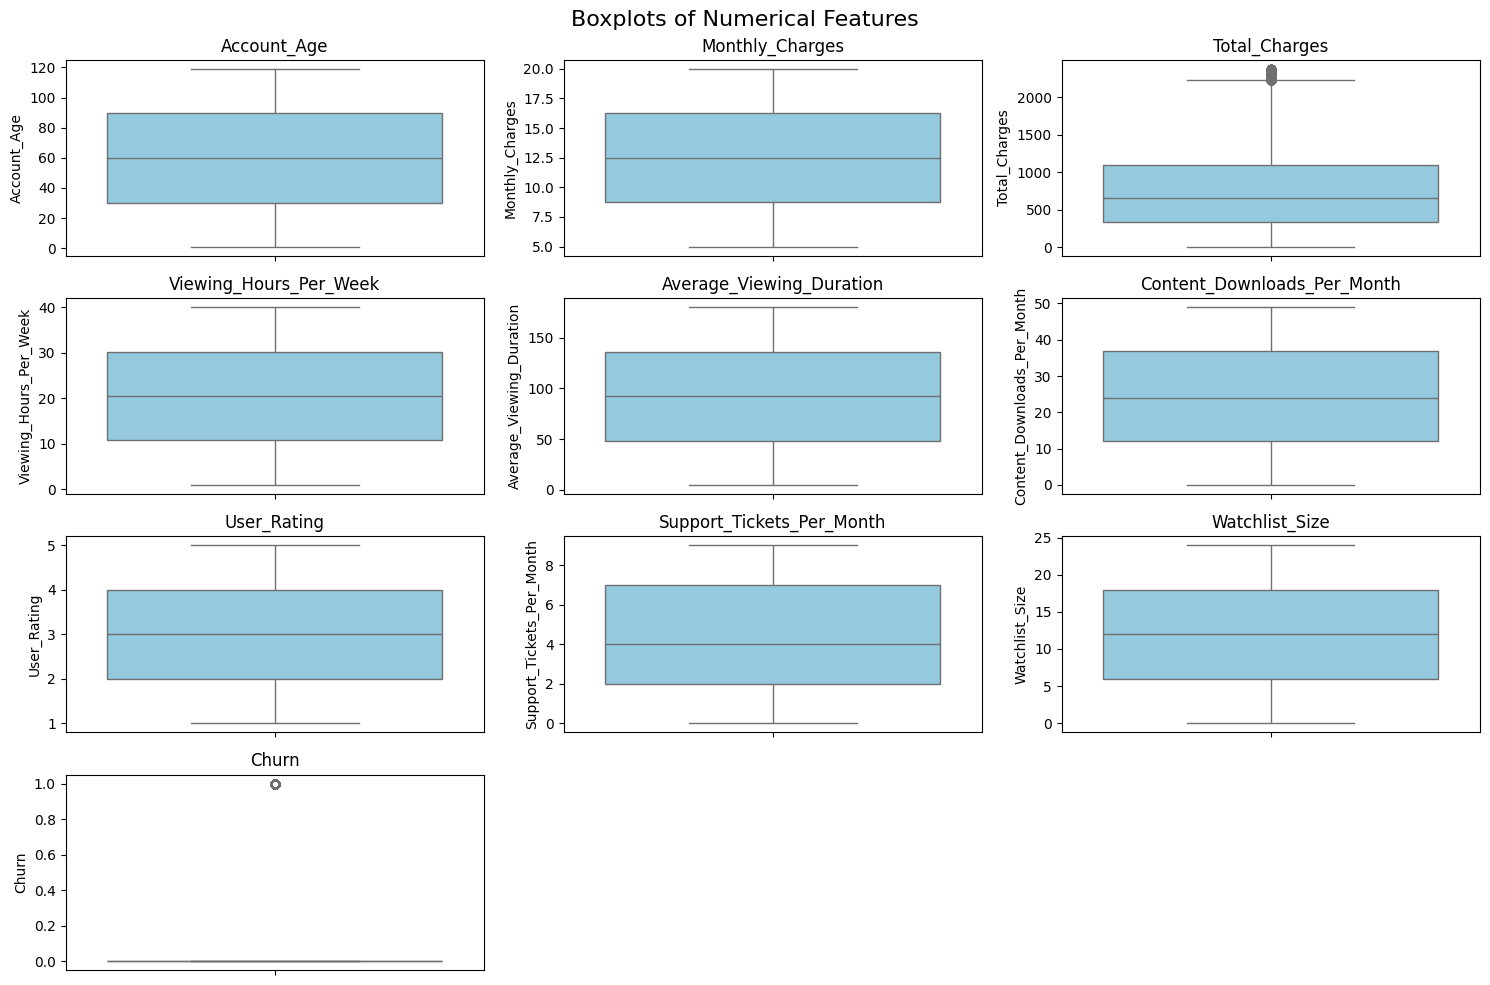

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_train.select_dtypes(include=['number']).columns


# Number of numerical columns
num_features = len(numeric_cols)

# Define subplot grid (adjust rows & cols based on number of features)
rows = (num_features // 3) + (num_features % 3 > 0)  # 3 columns per row
cols = 3

# Set figure size
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
fig.suptitle("Boxplots of Numerical Features", fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_train[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")  # Remove x-axis label

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Adjust title spacing
plt.show()


# Numerical Data Distribution

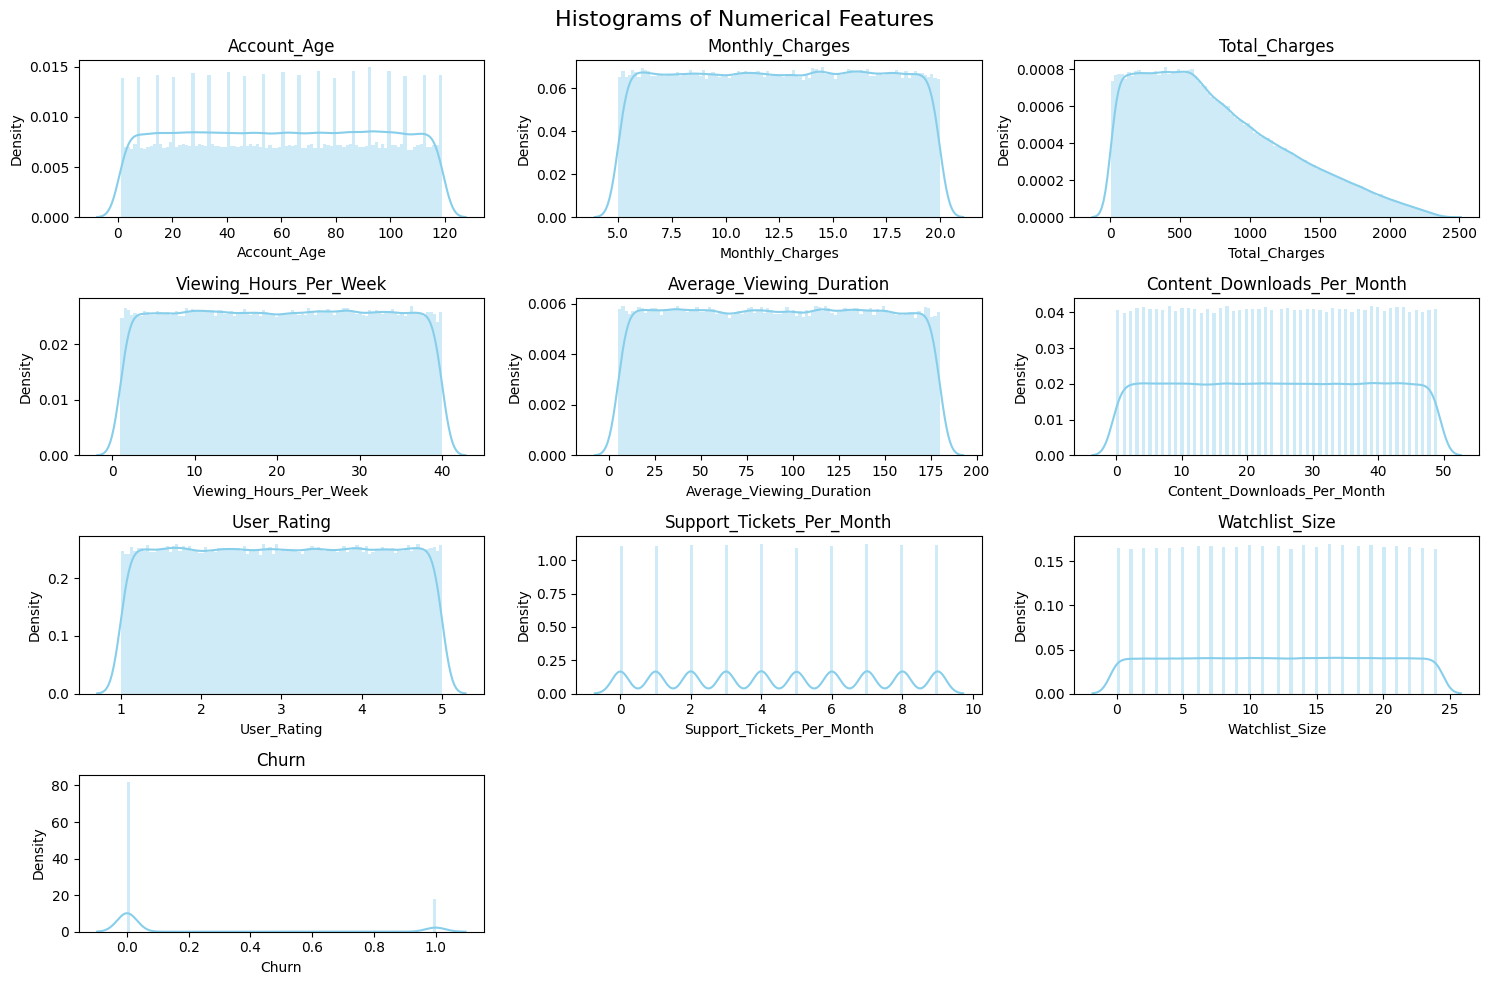

In [23]:
import warnings
warnings.filterwarnings("ignore")

# Select numeric columns
numeric_cols = df_train.select_dtypes(include=['number']).columns

# Number of numerical columns
num_features = len(numeric_cols)

# Define subplot grid (adjust rows & cols based on number of features)
rows = (num_features // 3) + (num_features % 3 > 0)  # 3 columns per row
cols = 3

# Set figure size
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
fig.suptitle("Histograms of Numerical Features", fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot histograms
for i, col in enumerate(numeric_cols):
    sns.distplot(df_train[col], bins=100, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(col)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Adjust title spacing
plt.show()

**Observation**

• The average Account Age is around 60 years, with a range from 1 to 119 years.

• The Monthly Charges range from $4.99 to $19.99, with a mean of $12.49.

• The Total Charges have a broad range from $4.99 to $2378.72, with an average of $750.74.

• On average, customers watch around 20.5 hours per week, with a viewing duration of 92.26 minutes per session.

• Customers download around 24.5 pieces of content per month on average, ranging from 0 to 49 downloads.

• The User Rating has an average of 3, with a range from 1 to 5.

• Support Tickets Per Month have an average of 4.5, with some users having up to 9 tickets per month. This indicates that some customers may be facing issues frequently, which could contribute to churn.

**Account_Age, Viewing_Hours_Per_Week, and Average_Viewing_Duration** appear to have a fairly uniform distribution, suggesting that users have a wide range of account ages, viewing hours, and durations without any dominant concentration around a central value. This indicates high variability.

**Monthly_Charges and Total_Charges** show a right-skewed distribution, most customers are concentrated around lower charge values, with fewer users incurring higher charges. This suggests a moderate spread but a higher density around smaller values.

**User_Rating and Watchlist_Size** display more uniform distributions with moderate spread, indicating that users have diverse preferences and ratings across the platform.

**Support_Tickets_Per_Month and Churn** are highly concentrated around lower values, implying that most customers have few support tickets and that churn is relatively rare in this dataset.

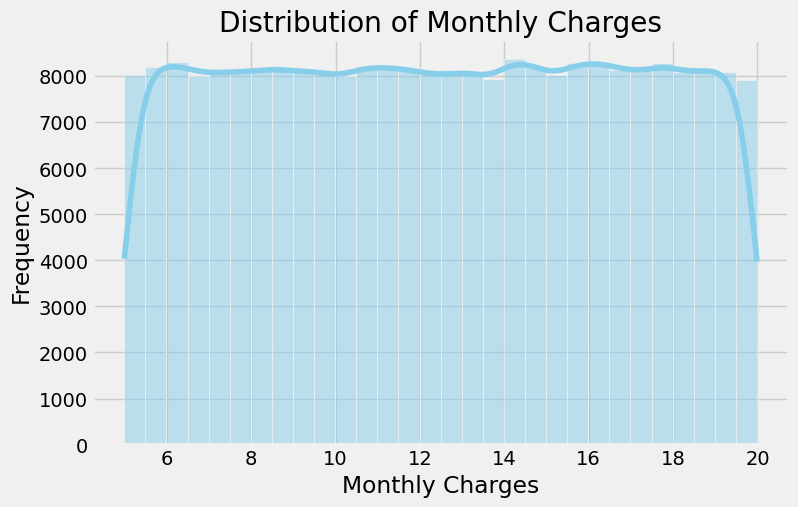

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_train["Monthly_Charges"],
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.savefig("monthly_charges_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#Target Variable Distribution

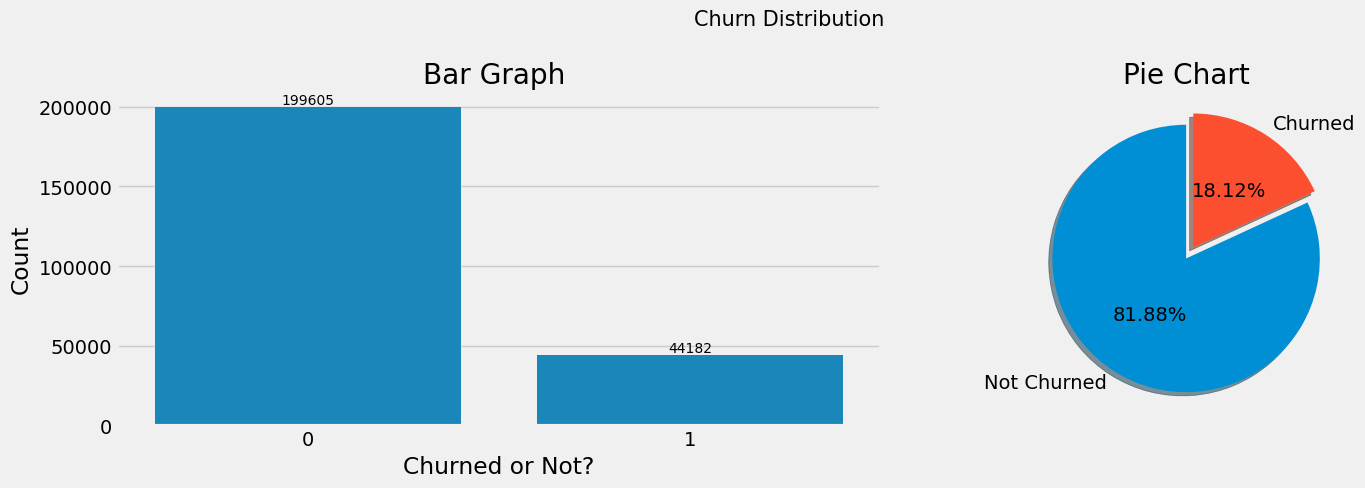

<Figure size 1600x500 with 0 Axes>

In [44]:
# Create subplots
plt.rcParams['figure.figsize'] = (16,5)
plt.style.use('fivethirtyeight')
fig, axes = plt.subplots(1, 2)

# Bar graph (subplot 1)
value_counts = df_train['Churn'].value_counts()
sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[0])
axes[0].set_title('Bar Graph ')
axes[0].set_xlabel('Churned or Not?')
axes[0].set_ylabel('Count')

# Add labels on top of the bars
for i, v in enumerate(value_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=10)

# Pie chart (subplot 2)
df_train['Churn'].value_counts().plot(
    kind='pie', explode=[0, 0.1], autopct='%.2f%%', startangle=90,
    labels=['Not Churned', 'Churned'], shadow=True, pctdistance=0.5, ax=axes[1])
axes[1].set_title('Pie Chart')
axes[1].axis('off')

# Set the title for the entire plot
plt.suptitle('Churn Distribution', fontsize=15)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()
plt.savefig("churn_distribution.png", dpi=300, bbox_inches="tight")


### Outliers

In [25]:
numerical_cols = ['Account_Age', 'Monthly_Charges', 'Total_Charges',
                     'Viewing_Hours_Per_Week', 'Content_Downloads_Per_Month','Average_Viewing_Duration',
                     'User_Rating', 'Support_Tickets_Per_Month', 'Watchlist_Size']

In [26]:
outliers = {}
for column in numeric_cols:
    Q1 = df_train[column].quantile(0.25)
    Q3 = df_train[column].quantile(0.75)
    IQR = Q3 - Q1
    outlier_condition = (df_train[column] < (Q1 - 1.5 * IQR)) | (df_train[column] > (Q3 + 1.5 * IQR))
    outliers[column] = df_train[column][outlier_condition]

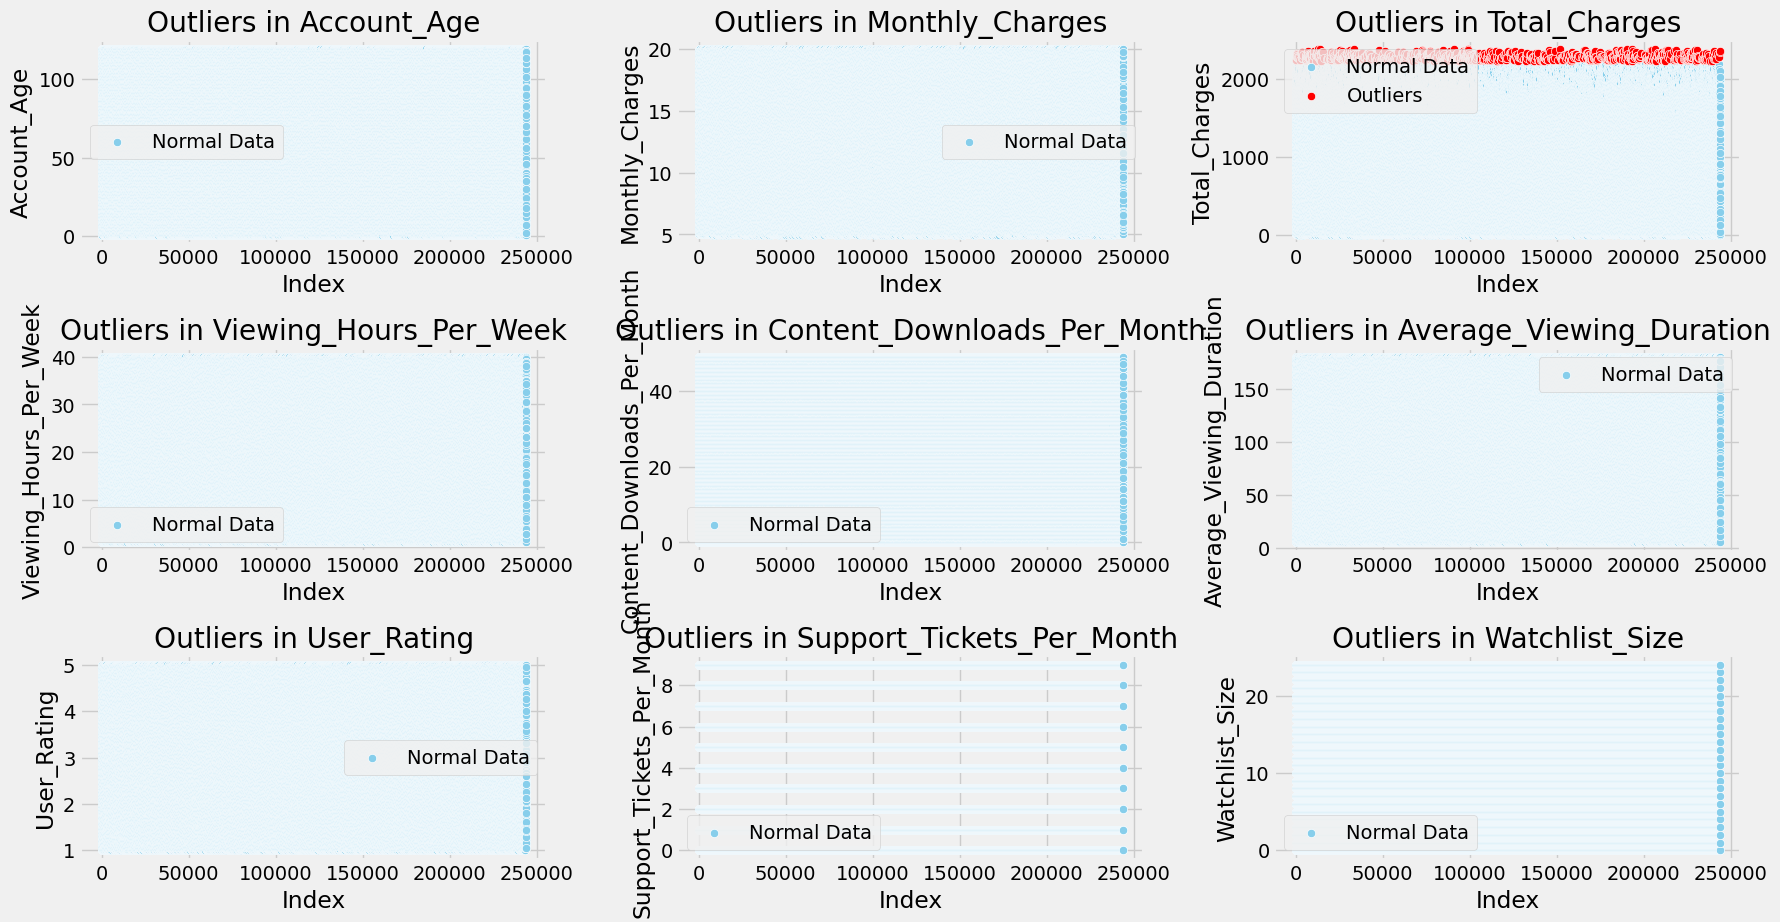

In [27]:
plt.figure(figsize=(18, 12))
for i, column in enumerate(numerical_cols, 1):
    #Change subplot to reflect grid
    plt.subplot(rows, cols, i)
    # Regular points
    sns.scatterplot(x=df_train.index, y=df_train[column], color='skyblue', label='Normal Data')
    # Highlight outliers
    sns.scatterplot(x=outliers[column].index, y=outliers[column], color='red', label='Outliers')
    plt.title(f'Outliers in {column}')
    plt.xlabel('Index')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

The scatter plot for **Total_Charges** reveals a significant number of outliers (marked in red), indicating unusually high charge values. These outliers may be caused by long-term subscribers, billing system errors, or potential fraudulent activities.These values are extreme but valid, applying a transformation can reduce their impact on analysis.

### Categorical Data Analysis

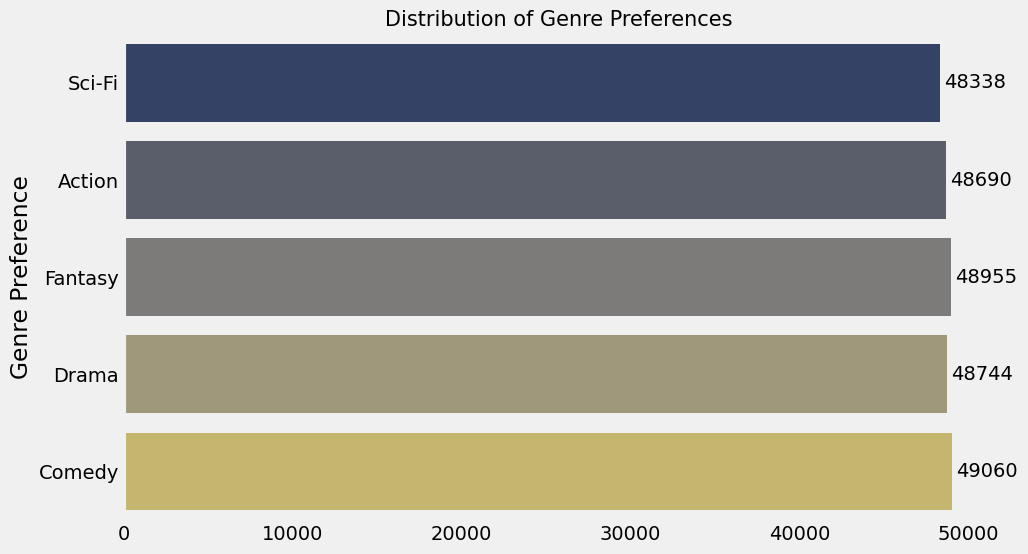

In [28]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(y=df_train['Genre_Preference'], palette='cividis')

# Add text labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.xlabel('')
plt.ylabel('Genre Preference')
plt.title('Distribution of Genre Preferences', fontsize=15)
plt.grid(axis='x')

plt.show()

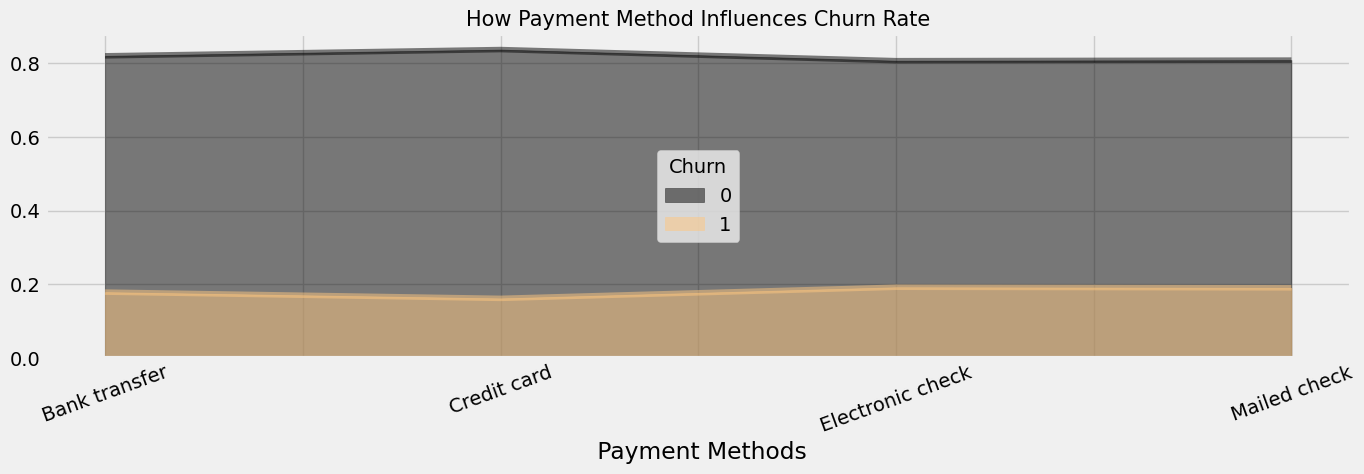

In [29]:
from matplotlib.colors import ListedColormap
plt.rcParams['figure.figsize'] = (15, 4)


x = pd.crosstab(df_train['Payment_Method'], df_train['Churn'])

# Generate colors for the area plot
colormap = ListedColormap(plt.cm.copper(np.linspace(0, 1, 3)))

# Normalize the values and create an area plot
x.div(x.sum(1).astype(float), axis=0).plot(kind='area', stacked=False, colormap=colormap)

# Set the title and labels
plt.title('How Payment Method Influences Churn Rate', fontsize=15)
plt.xticks(rotation=20)
plt.xlabel(' Payment Methods')

# Show the plot
plt.show()

The churn rate appears to be relatively consistent across different payment methods, with a higher proportion of non-churned customers (0) compared to churned customers (1). However, electronic check and mailed check seems to have a slightly higher churn rate than other 2 methods.

### Categorical & Numerical Variable Analysis

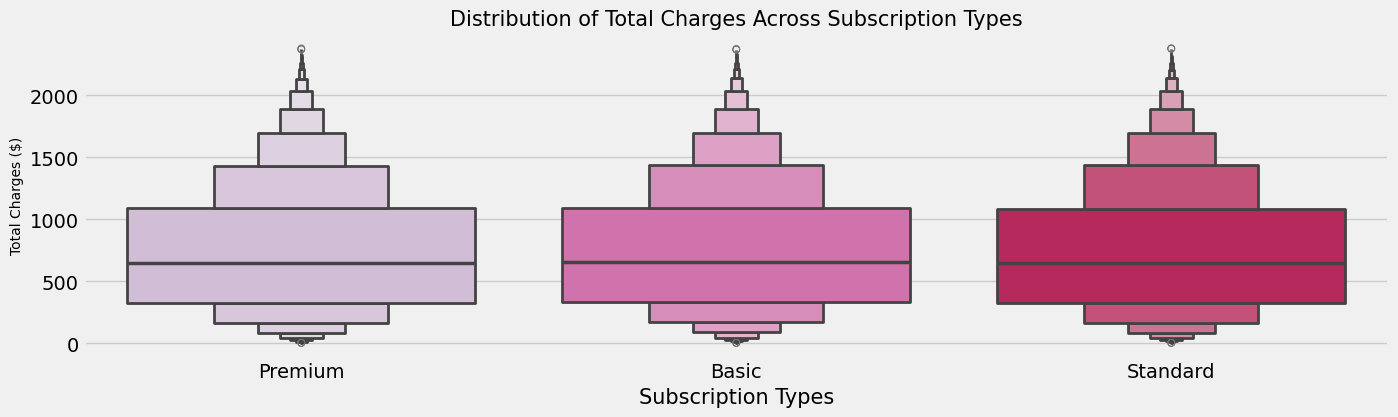

In [30]:
plt.rcParams['figure.figsize'] = (15, 4)


sns.boxenplot(x='Subscription_Type', y='Total_Charges', data=df_train, palette='PuRd')

plt.xlabel('Subscription Types', fontsize=15)
plt.ylabel('Total Charges ($)', fontsize=10)
plt.title('Distribution of Total Charges Across Subscription Types', fontsize=15)

plt.show()

The distribution of total charges is similar across all subscription types, with a wide range of values and some outliers at higher charges. The median total charges appear to be nearly identical across Premium, Basic, and Standard plans.

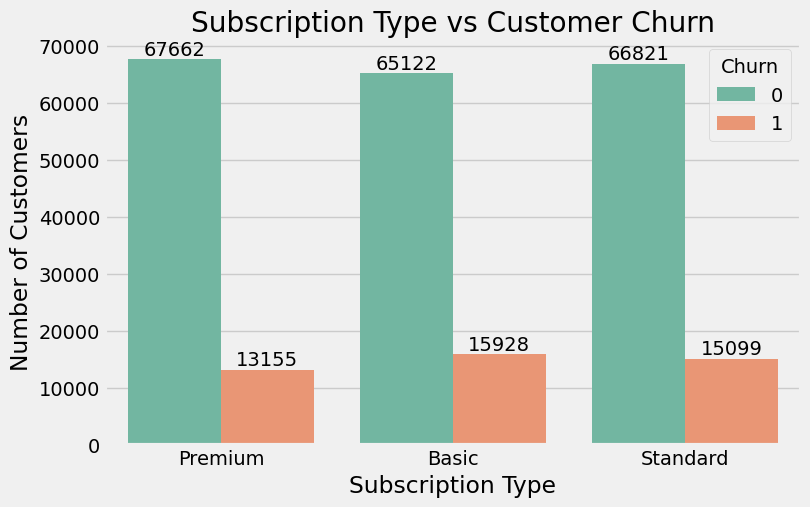

In [48]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_train,
    x="Subscription_Type",
    hue="Churn",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Subscription Type vs Customer Churn")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")

plt.savefig("subscription_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
@interact
def group_operations(churn = ['Churn'],  # Dropdown with only 'Churn'
                     category = list(df_train.select_dtypes('object').columns.difference(['Churn'])),
                     numeric = list(df_train.select_dtypes('number').columns)[1:]):

    return df_train[[churn, category, numeric]].groupby([churn, category]).agg('count').style.background_gradient(cmap='Wistia')


interactive(children=(Dropdown(description='churn', options=('Churn',), value='Churn'), Dropdown(description='…

In [32]:
@interact
def group_operations(churn = ['Churn'],  # Dropdown for Churn
                     category = list(df_train.select_dtypes('object').columns.difference(['Churn'])),
                     numeric = list(df_train.select_dtypes('number').columns)[1:]):

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Bar plot for categorical variable distribution across Churn
    sns.countplot(x=category, hue=churn, data=df_train, palette="coolwarm", ax=axes[0])
    axes[0].set_title(f"Distribution of {category} by {churn}")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

    # Box plot for numerical variable across Churn
    sns.boxplot(x=churn, y=numeric, data=df_train, palette="coolwarm", ax=axes[1])
    axes[1].set_title(f"Distribution of {numeric} by {churn}")

    plt.tight_layout()
    plt.show()


interactive(children=(Dropdown(description='churn', options=('Churn',), value='Churn'), Dropdown(description='…

In [33]:
from scipy import stats

# Selecting only numerical columns
numerical_cols = df_train.select_dtypes(include=['number']).columns.difference(['CustomerID'])

@interact
def check_distribution(column=list(numerical_cols)):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram + KDE Plot
    sns.histplot(df_train[column], bins=30, kde=True, ax=axes[0], color='royalblue')
    axes[0].set_title(f'Histogram & KDE of {column}')

    # Q-Q Plot
    stats.probplot(df_train[column].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {column}')

    # Box Plot
    sns.boxplot(x=df_train[column], ax=axes[2], color='tomato')
    axes[2].set_title(f'Box Plot of {column}')

    plt.show()

    # Skewness Calculation
    skewness = df_train[column].skew()
    print(f"\nSkewness of {column}: {skewness:.2f}")

    # Interpretation
    if skewness > 1:
        print("The distribution is **right-skewed (positively skewed)**. This suggests potential outliers on the higher end.")
    elif skewness < -1:
        print("The distribution is **left-skewed (negatively skewed)**. There may be outliers on the lower end.")
    else:
        print("The distribution is approximately **normal or symmetric**.")


interactive(children=(Dropdown(description='column', options=('Account_Age', 'Average_Viewing_Duration', 'Chur…

In [34]:
cat_columns= df_train.select_dtypes(include=['object','category']).columns

print(cat_columns)

Index(['Subscription_Type', 'Payment_Method', 'Paperless_Billing',
       'Content_Type', 'Multi_Device_Access', 'Device_Registered',
       'Genre_Preference', 'Gender', 'Parental_Control', 'Subtitles_Enabled',
       'Customer_ID'],
      dtype='object')


In [35]:
df_encoded = df_train.copy()

# Apply Label Encoding to categorical columns
label_encoders = {}
cat_columns = df_encoded.select_dtypes(include=['object']).columns  # Selecting categorical columns

for col in cat_columns:
    label_encoders[col] = LabelEncoder()
    df_encoded[col] = label_encoders[col].fit_transform(df_encoded[col])


### Correlation Analysis

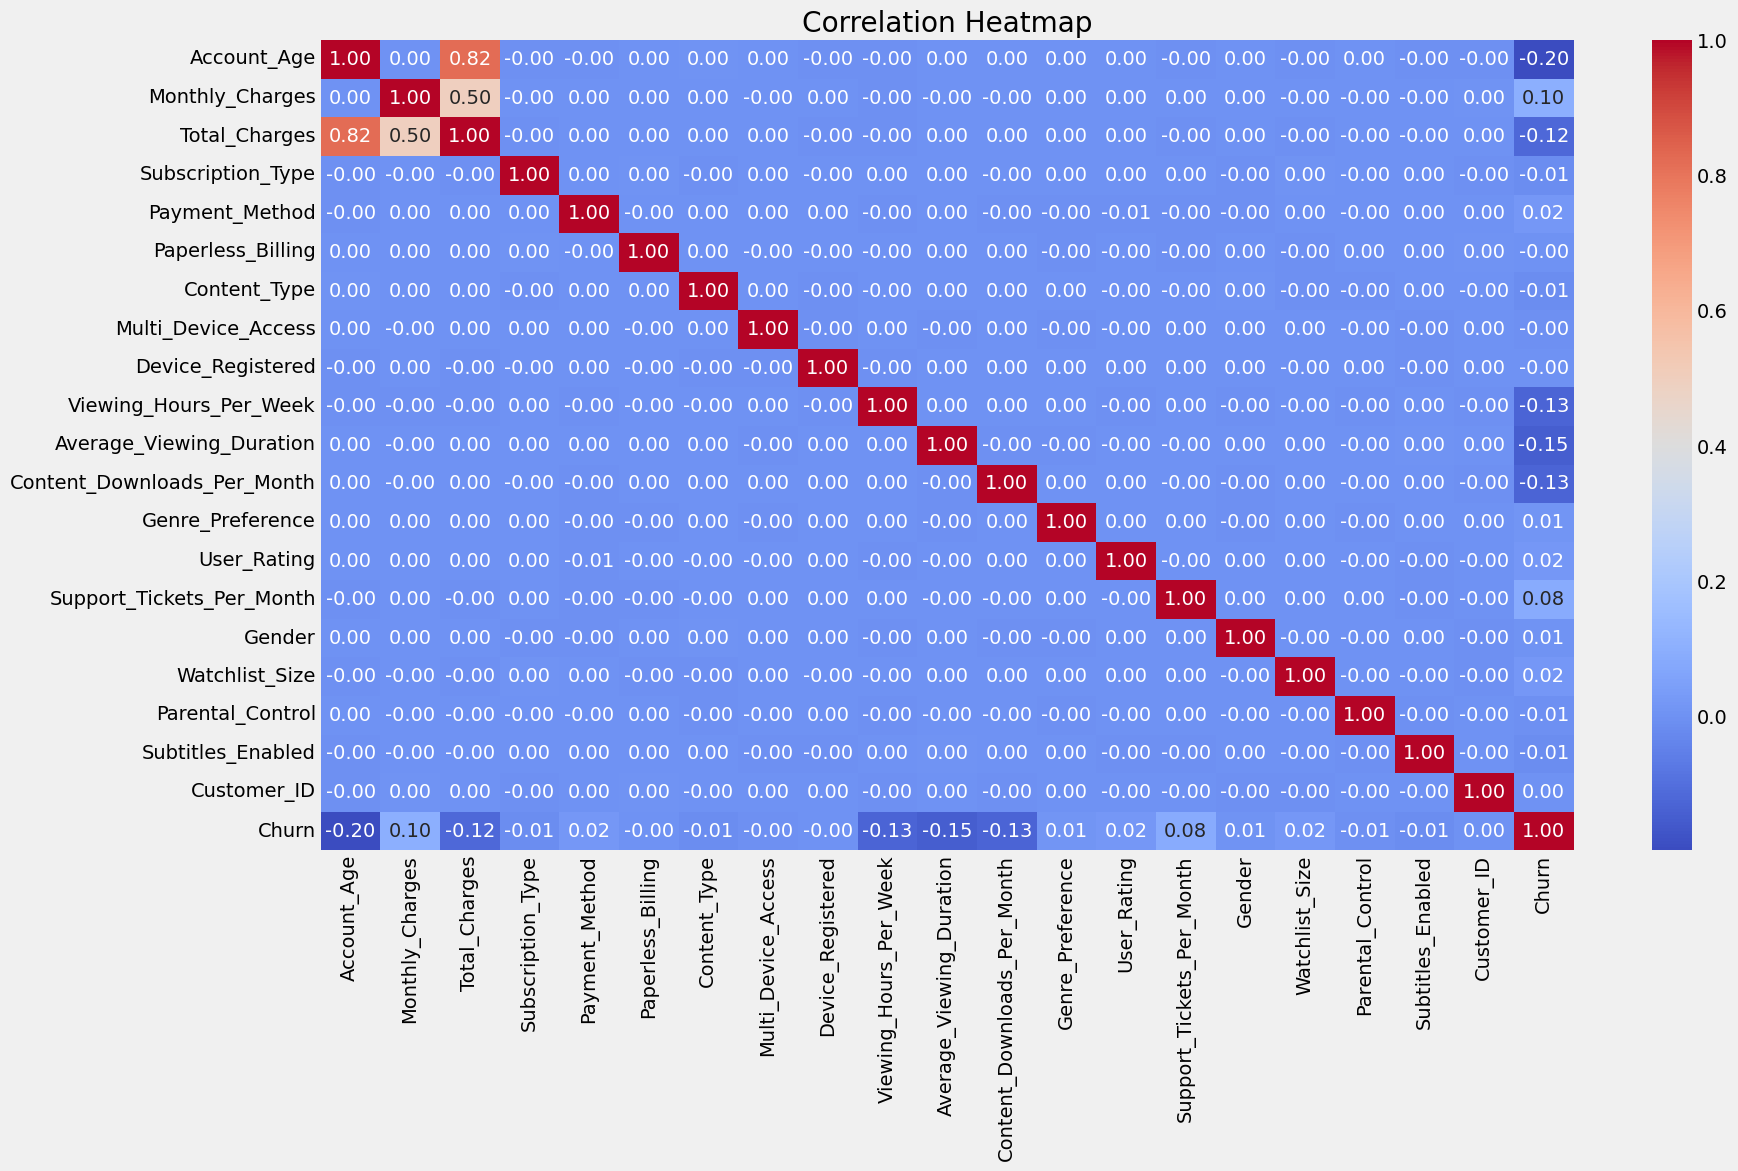

In [45]:
numeric_df = df_encoded.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(18,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## building the model

In [38]:
X = df_encoded.drop(["Churn", "Customer_ID"], axis=1)
y = df_encoded["Churn"]

CustomerID is a unique identifier and does not contribute to predicting customer churn, so it is removed. Churn is separated as the target variable.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.822244554739735
[[39327   641]
 [ 8026   764]]
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     39968
           1       0.54      0.09      0.15      8790

    accuracy                           0.82     48758
   macro avg       0.69      0.54      0.53     48758
weighted avg       0.78      0.82      0.77     48758



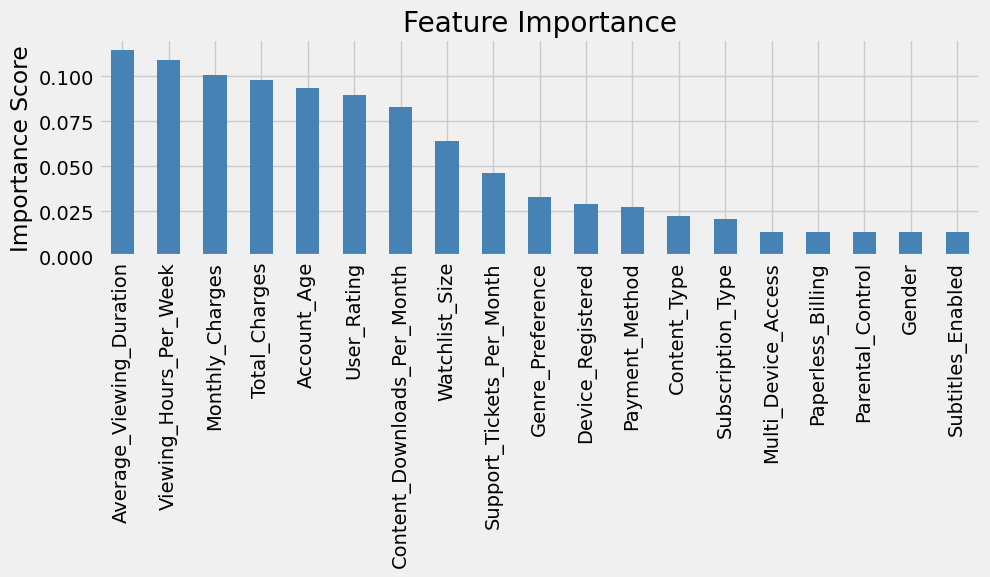

In [46]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Feature Importance Analysis

- Average Viewing Duration and Viewing Hours Per Week are the most influential predictors of customer churn, indicating that customer engagement is strongly associated with retention.
- Financial attributes such as Monthly Charges and Total Charges also contribute significantly to the model's predictions.
- Customer behavior features including User Rating, Content Downloads, and Watchlist Size have moderate predictive importance.
- Demographic and preference-related features such as Gender, Parental Control, and Subtitles Enabled exhibit relatively low importance, suggesting they have minimal impact on churn prediction in this dataset.

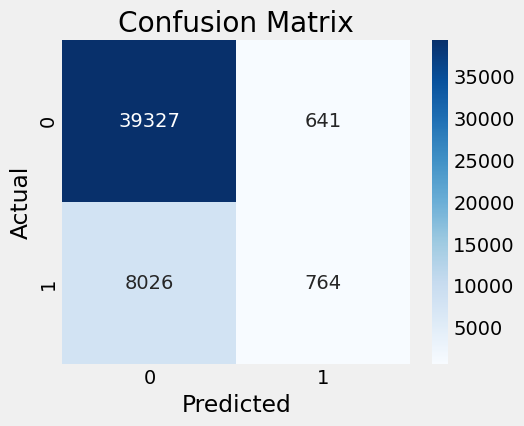

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()